In [1]:
import os
import math
import copy
import random
import zipfile

import numpy as np
import pandas as pd
import scipy.io
import requests

import mne
import gdown
from tqdm import tqdm

import seaborn as sn
import matplotlib.pyplot as plt

# Torch
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchsummary import summary
from torch.autograd import Variable
from torch.utils.data import DataLoader, TensorDataset, random_split

# Scikit-Learn
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split

import timm
import torch.nn.functional as F
from scipy import signal
from pyts.image import GramianAngularField 
import librosa
import cv2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


/media/neurone-pc12/Volume/Milone/EEG/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
raw_data_folder = "content/raw_data/"
cleaned_data_folder_first = "content/cleaned_data/first_session/"

files = os.listdir(raw_data_folder)
filtered_files_T = [f for f in files if f.endswith("T.gdf")]

raw_list_first = []

for file in filtered_files_T:
    file_path = os.path.join(raw_data_folder, file)

    # Leggo raw
    raw = mne.io.read_raw_gdf(
        file_path,
        eog=["EOG-left", "EOG-central", "EOG-right"],
        preload=True
    )

    # Rimuovo canali EOG
    raw.drop_channels(["EOG-left", "EOG-central", "EOG-right"])

    # Filtro banda 4–40 Hz
    raw.filter(l_freq=4, h_freq=40, method="iir")

    # Notch a 50 Hz
    raw.notch_filter(freqs=50)

    # Salvo singolo soggetto
    new_file_path = os.path.join(cleaned_data_folder_first, file[:-4] + ".fif")
    raw.save(new_file_path, overwrite=True)

    raw_list_first.append(raw)

# Concatenazione
final_raw_first = mne.concatenate_raws(raw_list_first)
first_session_path = os.path.join(cleaned_data_folder_first, "First_Session_Subjects.fif")
final_raw_first.save(first_session_path, overwrite=True)

print(f"Processati {len(filtered_files_T)} file T.gdf -> {cleaned_data_folder_first}")


Extracting GDF parameters from content/raw_data/A08T.gdf...
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG
Creating raw.info structure...


/usr/lib/python3.12/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Reading 0 ... 675269  =      0.000 ...  2701.076 secs...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 4 - 40 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 4.00, 40.00 Hz: -6.02, -6.02 dB

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.38
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 49.12 Hz)
- Upper passband edge: 50.62 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 50.88 Hz)
- Filter length: 1651 samples (6.604 s)

Writing /media/neurone-pc12/Volume/Milone/EEG/content/cleaned_data

/tmp/ipykernel_27912/2508117842.py:30: RuntimeWarning: This filename (/media/neurone-pc12/Volume/Milone/EEG/content/cleaned_data/first_session/A08T.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw.save(new_file_path, overwrite=True)
/usr/lib/python3.12/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 4 - 40 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 4.00, 40.00 Hz: -6.02, -6.02 dB

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.38
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 49.12 Hz)
- Upper passband edge: 50.62 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 50.88 Hz)
- Filter length: 1651 samples (6.604 s)

Writing /media/neurone-pc12/Volume/Milone/EEG/content/cleaned_data/first_session/A05T.fif
Closing /media/neurone-pc12/Volum

...

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 4 - 40 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 4.00, 40.00 Hz: -6.02, -6.02 dB

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.38
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 49.12 Hz)
- Upper passband edge: 50.62 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 50.88 Hz)
- Filter length: 1651 samples (6.604 s)

Writing /media/neurone-pc12/Volume/Milone/EEG/content/cleaned_data/first_session/A04T.fif
Closing /media/neurone-pc12/Volum

/tmp/ipykernel_27912/2508117842.py:30: RuntimeWarning: This filename (/media/neurone-pc12/Volume/Milone/EEG/content/cleaned_data/first_session/A04T.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw.save(new_file_path, overwrite=True)


Writing /media/neurone-pc12/Volume/Milone/EEG/content/cleaned_data/first_session/First_Session_Subjects.fif


/tmp/ipykernel_27912/2508117842.py:37: RuntimeWarning: This filename (/media/neurone-pc12/Volume/Milone/EEG/content/cleaned_data/first_session/First_Session_Subjects.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  final_raw_first.save(first_session_path, overwrite=True)


Closing /media/neurone-pc12/Volume/Milone/EEG/content/cleaned_data/first_session/First_Session_Subjects.fif
[done]
Processati 9 file T.gdf -> content/cleaned_data/first_session/


In [3]:
# Eventi ed epochs prima sessione
events_first = mne.events_from_annotations(final_raw_first)
print(events_first[1])  # dizionario mapping

epochs_first = mne.Epochs(
    final_raw_first,
    events_first[0],
    event_id=[7, 8, 9, 10],
    tmin=0,
    tmax=4,
    reject=None,
    baseline=None,
    preload=True
)

first_session_data = epochs_first.get_data(copy=True)
first_session_labels = epochs_first.events[:, -1]

print("First_session_dataset shape:", first_session_data.shape)

Used Annotations descriptions: [np.str_('1023'), np.str_('1072'), np.str_('276'), np.str_('277'), np.str_('32766'), np.str_('768'), np.str_('769'), np.str_('770'), np.str_('771'), np.str_('772')]
{np.str_('1023'): 1, np.str_('1072'): 2, np.str_('276'): 3, np.str_('277'): 4, np.str_('32766'): 5, np.str_('768'): 6, np.str_('769'): 7, np.str_('770'): 8, np.str_('771'): 9, np.str_('772'): 10}
Not setting metadata
2592 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 2592 events and 1001 original time points ...
0 bad epochs dropped
First_session_dataset shape: (2592, 22, 1001)


In [4]:
raw_data_folder = "content/raw_data/"
cleaned_data_folder_second = "content/cleaned_data/second_session/"
mat_folder = "content/second_session_labels/"

mat_files = os.listdir(mat_folder)
filtered_mat_labels = [f for f in mat_files if f.endswith("E.mat")]

files = os.listdir(raw_data_folder)
filtered_files_E = [f for f in files if f.endswith("E.gdf")]

raw_list_second = []
second_session_labels = np.array([])

for file in filtered_files_E:
    file_path = os.path.join(raw_data_folder, file)

    # Lettura gdf
    raw = mne.io.read_raw_gdf(
        file_path,
        eog=["EOG-left", "EOG-central", "EOG-right"],
        preload=True
    )

    raw.drop_channels(["EOG-left", "EOG-central", "EOG-right"])
    raw.filter(l_freq=4, h_freq=40, method="iir")

    new_file_path = os.path.join(cleaned_data_folder_second, file[:-4] + ".fif")
    raw.save(new_file_path, overwrite=True)

    raw_list_second.append(raw)

    # Mat corrispondente
    mat_file_name = file.replace(".gdf", ".mat")
    mat_file_path = os.path.join(mat_folder, mat_file_name)
    print(f"data:{file}, label:{mat_file_name}")

    if os.path.exists(mat_file_path):
        mat_data = scipy.io.loadmat(mat_file_path)
        class_labels = mat_data.get("classlabel", [])

        if class_labels.size > 0:
            class_labels_array = np.array(class_labels, dtype=int).flatten()
            second_session_labels = np.concatenate((second_session_labels, class_labels_array))
        else:
            print(f"Warning: 'classlabel' vuoto in {mat_file_name}.")
    else:
        print(f"Warning: {mat_file_name} non trovato.")


Extracting GDF parameters from content/raw_data/A07E.gdf...
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG
Creating raw.info structure...
Reading 0 ... 673134  =      0.000 ...  2692.536 secs...


/usr/lib/python3.12/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 4 - 40 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 4.00, 40.00 Hz: -6.02, -6.02 dB

Writing /media/neurone-pc12/Volume/Milone/EEG/content/cleaned_data/second_session/A07E.fif
Closing /media/neurone-pc12/Volume/Milone/EEG/content/cleaned_data/second_session/A07E.fif
[done]
data:A07E.gdf, label:A07E.mat
Extracting GDF parameters from content/raw_data/A01E.gdf...
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG
Creating raw.info structure...
Reading 0 ... 686999  =      0.000 ...  2747.996 secs...


/tmp/ipykernel_27912/3566498056.py:28: RuntimeWarning: This filename (/media/neurone-pc12/Volume/Milone/EEG/content/cleaned_data/second_session/A07E.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw.save(new_file_path, overwrite=True)
/usr/lib/python3.12/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 4 - 40 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 4.00, 40.00 Hz: -6.02, -6.02 dB

Writing /media/neurone-pc12/Volume/Milone/EEG/content/cleaned_data/second_session/A01E.fif
Closing /media/neurone-pc12/Volume/Milone/EEG/content/cleaned_data/second_session/A01E.fif
[done]
data:A01E.gdf, label:A01E.mat
Extracting GDF parameters from content/raw_data/A05E.gdf...
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG
Creating raw.info structure...
Reading 0 ... 679862  =      0.000 ...  2719.448 secs...


...

/tmp/ipykernel_27912/3566498056.py:28: RuntimeWarning: This filename (/media/neurone-pc12/Volume/Milone/EEG/content/cleaned_data/second_session/A02E.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw.save(new_file_path, overwrite=True)
/usr/lib/python3.12/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 4 - 40 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 4.00, 40.00 Hz: -6.02, -6.02 dB

Writing /media/neurone-pc12/Volume/Milone/EEG/content/cleaned_data/second_session/A03E.fif
Closing /media/neurone-pc12/Volume/Milone/EEG/content/cleaned_data/second_session/A03E.fif
[done]
data:A03E.gdf, label:A03E.mat
Extracting GDF parameters from content/raw_data/A08E.gdf...
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG
Creating raw.info structure...
Reading 0 ... 687791  =      0.000 ...  2751.164 secs...


/tmp/ipykernel_27912/3566498056.py:28: RuntimeWarning: This filename (/media/neurone-pc12/Volume/Milone/EEG/content/cleaned_data/second_session/A03E.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw.save(new_file_path, overwrite=True)
/usr/lib/python3.12/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 4 - 40 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 4.00, 40.00 Hz: -6.02, -6.02 dB

Writing /media/neurone-pc12/Volume/Milone/EEG/content/cleaned_data/second_session/A08E.fif
Closing /media/neurone-pc12/Volume/Milone/EEG/content/cleaned_data/second_session/A08E.fif
[done]
data:A08E.gdf, label:A08E.mat


/tmp/ipykernel_27912/3566498056.py:28: RuntimeWarning: This filename (/media/neurone-pc12/Volume/Milone/EEG/content/cleaned_data/second_session/A08E.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw.save(new_file_path, overwrite=True)


In [5]:
# Concatenazione seconda sessione
final_raw_second = mne.concatenate_raws(raw_list_second)
second_session_path = os.path.join(cleaned_data_folder_second, "Second_Session_Subjects.fif")
final_raw_second.save(second_session_path, overwrite=True)

Writing /media/neurone-pc12/Volume/Milone/EEG/content/cleaned_data/second_session/Second_Session_Subjects.fif


/tmp/ipykernel_27912/2992527919.py:4: RuntimeWarning: This filename (/media/neurone-pc12/Volume/Milone/EEG/content/cleaned_data/second_session/Second_Session_Subjects.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  final_raw_second.save(second_session_path, overwrite=True)


Closing /media/neurone-pc12/Volume/Milone/EEG/content/cleaned_data/second_session/Second_Session_Subjects.fif
[done]


[PosixPath('/media/neurone-pc12/Volume/Milone/EEG/content/cleaned_data/second_session/Second_Session_Subjects.fif')]

In [6]:
# Eventi ed epochs seconda sessione
events_second = mne.events_from_annotations(final_raw_second)
print(events_second[1])

epochs_second = mne.Epochs(
    final_raw_second,
    events_second[0],
    event_id=7,
    tmin=0,
    tmax=4,
    reject=None,
    baseline=None,
    preload=None
)

second_session_data = epochs_second.get_data(copy=True)

print("Second Session Dataset shape:", second_session_data.shape)


Used Annotations descriptions: [np.str_('1023'), np.str_('1072'), np.str_('276'), np.str_('277'), np.str_('32766'), np.str_('768'), np.str_('783')]
{np.str_('1023'): 1, np.str_('1072'): 2, np.str_('276'): 3, np.str_('277'): 4, np.str_('32766'): 5, np.str_('768'): 6, np.str_('783'): 7}
Not setting metadata
2592 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 2592 events and 1001 original time points ...
0 bad epochs dropped
Second Session Dataset shape: (2592, 22, 1001)


In [7]:
# Normalizzazione labels a [0, 1, 2, 3]
y_train = first_session_labels - np.min(first_session_labels)
y_test = second_session_labels - np.min(second_session_labels)

# Z-score dei dati
X_first_session = (first_session_data - np.mean(first_session_data)) / np.std(first_session_data)
X_second_session = (second_session_data - np.mean(second_session_data)) / np.std(second_session_data)

X = np.concatenate((X_first_session, X_second_session))
y = np.concatenate((y_train, y_test))

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.1,
    random_state=42,
    stratify=y
)

# Tensors
X_train = torch.Tensor(X_train).unsqueeze(1).to(device)
X_test = torch.Tensor(X_test).unsqueeze(1).to(device)
y_train = torch.LongTensor(y_train).to(device)
y_test = torch.LongTensor(y_test).to(device)

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

print("Size of X_train:", X_train.size())
print("Size of X_test:", X_test.size())
print("Size of y_train:", y_train.size())
print("Size of y_test:", y_test.size())


Size of X_train: torch.Size([4665, 1, 22, 1001])
Size of X_test: torch.Size([519, 1, 22, 1001])
Size of y_train: torch.Size([4665])
Size of y_test: torch.Size([519])


In [8]:
class TrainModel:
    def __init__(self):
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    def train_model(self, model, train_dataset, learning_rate=0.001, batch_size=64, epochs=500):
        model = model.to(self.device)
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr=learning_rate)
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

        highest_train_accuracy = 0.0

        for epoch in range(epochs):
            model.train()
            running_loss = 0.0
            correct = 0
            total = 0

            for inputs, labels in train_loader:
                inputs = inputs.to(self.device)
                labels = labels.to(self.device)

                optimizer.zero_grad()
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

            epoch_loss = running_loss / len(train_loader.dataset)
            epoch_accuracy = correct / total

            if epoch_accuracy > highest_train_accuracy:
                highest_train_accuracy = epoch_accuracy
                print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}, Accuracy: {(epoch_accuracy*100):.2f}%")

        average_loss = running_loss / len(train_loader.dataset)
        print("Average Loss:", average_loss)
        print("Highest Train Accuracy:", highest_train_accuracy)

        torch.save(model.state_dict(), "eegnet_model.pth")
        return model


In [9]:
class EvalModel:
    def __init__(self, model):
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model = model.to(self.device)

    def test_model(self, test_dataset):
        self.model.eval()
        correct = 0
        total = 0
        test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs = inputs.to(self.device)
                labels = labels.to(self.device)
                outputs = self.model(inputs)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        accuracy = (correct / total) * 100
        print("/------------------------------/")
        print(f"Test Accuracy: {accuracy:.2f}%")
        print("/------------------------------/")
        return accuracy

    def plot_confusion_matrix(self, test_dataset, classes):
        self.model.eval()
        y_pred = []
        y_true = []
        test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs = inputs.to(self.device)
                labels = labels.to(self.device)
                outputs = self.model(inputs)
                _, predicted = torch.max(outputs.data, 1)
                y_pred.append(predicted.item())
                y_true.append(labels.item())

        cf_matrix = confusion_matrix(y_true, y_pred)
        cf_matrix = cf_matrix.astype("float") / cf_matrix.sum(axis=1)[:, np.newaxis]

        df_cm = pd.DataFrame(cf_matrix, index=classes, columns=classes)

        plt.figure(figsize=(10, 7))
        sn.heatmap(df_cm, annot=True, cmap="Blues", fmt=".2f")
        plt.xlabel("Predicted labels")
        plt.ylabel("True labels")
        plt.title("Confusion Matrix")
        plt.savefig("confusion_matrix_model.png")
        plt.show()


In [10]:
def create_spectrograms(X_data, fs=250, n_fft=256, n_mels=64, target_size=(224, 224)):
    """
    Crea spettrogrammi da dati EEG (trial).

    Args:
        X_data: (N_trials, n_channels, n_times)
        fs: frequenza campionamento
        n_fft, n_mels: parametri STFT
        target_size: dimensione finale per ViT
    """
    spectrograms = []

    for trial in X_data:
        # Calcolo spettrogramma per ogni canale
        specs = []
        for ch in trial:
            spec = np.abs(signal.stft(ch, fs=fs, nperseg=n_fft, return_onesided=False)[2])
            spec = librosa.feature.melspectrogram(S=spec, n_mels=n_mels)  # Mel-scale
            spec = librosa.power_to_db(spec, ref=np.max)
            specs.append(spec)

        # Stack canali: (n_channels, freq, time)
        specs = np.stack(specs, axis=0)

        # Media su canali → (freq, time) → (H, W)
        spec_img = np.mean(specs, axis=0)

        # Resize a target_size
        spec_img = cv2.resize(spec_img, target_size)
        spec_img = (spec_img - spec_img.mean()) / (spec_img.std() + 1e-8)
        spectrograms.append(spec_img)

    return np.array(spectrograms)[:, np.newaxis, :, :]  # (N, 1, H, W)


In [11]:
def prepare_vit_input_corrected(X_data, method="gaf", target_size=(224, 224)):
    """
    Versione corretta: gestisce shape EEG → immagini GAF univariate.
    X_data: (N_trials, n_channels, n_times) o (N_trials, 1, n_channels, n_times)
    """
    # Gestione shape
    if len(X_data.shape) == 4:
        X_data = X_data.squeeze(1)

    N_trials = X_data.shape[0]
    images = []

    for i in tqdm(range(N_trials), desc="Creazione GAF"):
        trial = X_data[i]  # (n_channels, n_times)

        if method == "gaf":
            # GAF sulla serie temporale media
            trial_mean = np.mean(trial, axis=0)
            
            # Check lunghezza per evitare ValueError
            if len(trial_mean) < target_size[0]:
                raise ValueError(f"Serie troppo corta: {len(trial_mean)} < {target_size[0]}")
            
            gaf = GramianAngularField(image_size=target_size[0], method='summation')
            gaf_img = gaf.fit_transform(trial_mean.reshape(1, -1))[0]

            # Normalizza z-score per ViT
            gaf_img = (gaf_img - gaf_img.mean()) / (gaf_img.std() + 1e-8)
            images.append(gaf_img)

        else:
            raise ValueError(f"Method '{method}' non supportato. Usa 'gaf'.")

    # Output: (N_trials, 1, H, W) per Conv2d/ViT
    return np.expand_dims(np.array(images), axis=1).astype(np.float32)

In [12]:
class EEGNetModel(nn.Module):  # EEGNET-8,2
    def __init__(
        self,
        chans=22,
        classes=4,
        time_points=1001,
        temp_kernel=32,
        f1=16,
        f2=32,
        d=2,
        pk1=8,
        pk2=16,
        dropout_rate=0.5,
        max_norm1=1,
        max_norm2=0.25
    ):
        super(EEGNetModel, self).__init__()

        # Calcolo dimensione layer fully-connected
        linear_size = (time_points // (pk1 * pk2)) * f2

        # Blocchi
        self.block1 = nn.Sequential(
            nn.Conv2d(1, f1, (1, temp_kernel), padding="same", bias=False),
            nn.BatchNorm2d(f1),
        )

        self.block2 = nn.Sequential(
            nn.Conv2d(f1, d * f1, (chans, 1), groups=f1, bias=False),  # depthwise
            nn.BatchNorm2d(d * f1),
            nn.ELU(),
            nn.AvgPool2d((1, pk1)),
            nn.Dropout(dropout_rate),
        )

        self.block3 = nn.Sequential(
            nn.Conv2d(d * f1, f2, (1, 16), groups=f2, bias=False, padding="same"),  # separable
            nn.Conv2d(f2, f2, kernel_size=1, bias=False),  # pointwise
            nn.BatchNorm2d(f2),
            nn.ELU(),
            nn.AvgPool2d((1, pk2)),
            nn.Dropout(dropout_rate),
        )

        self.flatten = nn.Flatten()
        self.fc = nn.Linear(linear_size, classes)

        self._apply_max_norm(self.block2[0], max_norm1)
        self._apply_max_norm(self.fc, max_norm2)

    def _apply_max_norm(self, layer, max_norm):
        for name, param in layer.named_parameters():
            if "weight" in name:
                param.data = torch.renorm(param.data, p=2, dim=0, maxnorm=max_norm)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.flatten(x)
        x = self.fc(x)
        return x


In [ ]:
# # Parametri
TARGET_SIZE = 224


# print("🎯 Ricreazione immagini con shape corretto...")
X_train_img = prepare_vit_input_corrected(
    X_train.cpu().numpy(),
    target_size=(TARGET_SIZE, TARGET_SIZE)
 )

X_test_img = prepare_vit_input_corrected(
     X_test.cpu().numpy(),
     target_size=(TARGET_SIZE, TARGET_SIZE) )

# Tensors FINALE: (N, 1, 224, 224)
X_train_vit = torch.FloatTensor(X_train_img).to(device)
X_test_vit = torch.FloatTensor(X_test_img).to(device)

print(f"✅ X_train_vit shape: {X_train_vit.shape}")  # Deve essere (N, 1, 224, 224)
print(f"✅ X_test_vit shape:  {X_test_vit.shape}")






Creazione GAF: 100%|██████████| 519/519 [00:00<00:00, 2675.59it/s]


✅ X_train_vit shape: torch.Size([4665, 1, 224, 224])
✅ X_test_vit shape:  torch.Size([519, 1, 224, 224])


In [15]:
# EEGViT model (copia dal tuo file)
class EEGViT(nn.Module):
    SUPPORTED_MODELS = [
        "vit_small_patch16_224",
        "vit_base_patch16_224",
        "deit_tiny_patch16_224",
    ]

    def __init__(self, n_channels=22, n_classes=4,
                 model_name="deit_tiny_patch16_224",
                 pretrained=True, dropout=0.5,
                 freeze_vit=False, target_size=224):
        super().__init__()

        assert model_name in self.SUPPORTED_MODELS, \
            f"model_name deve essere uno di: {self.SUPPORTED_MODELS}"

        # 1) Proiezione canali EEG → 3 (RGB-like)
        self.channel_proj = nn.Sequential(
            nn.Conv2d(n_channels, 3, kernel_size=1, bias=False),
            nn.BatchNorm2d(3),
        )

        # 2) ViT pretrainato — senza testa
        self.vit = timm.create_model(
            model_name,
            pretrained=pretrained,
            num_classes=0,
            img_size=target_size,
        )

        if freeze_vit:
            for param in self.vit.parameters():
                param.requires_grad = False
            print("ViT congelato")

        # 3) Classification head
        embed_dim = self.vit.embed_dim
        self.classifier = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Dropout(dropout),
            nn.Linear(embed_dim, 128),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(128, n_classes),
        )

        total = sum(p.numel() for p in self.parameters())
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f"EEGViT ({model_name}): {total:,} params | "
              f"{trainable:,} trainabili | embed_dim={embed_dim}")

    def forward(self, x):
        x = self.channel_proj(x)
        x = self.vit(x)
        return self.classifier(x)


In [16]:
input_size = (1, 22, 1001)
eegnet_model = EEGNetModel().to(device)
summary(eegnet_model, input_size)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 16, 22, 1001]             512
       BatchNorm2d-2         [-1, 16, 22, 1001]              32
            Conv2d-3          [-1, 32, 1, 1001]             704
       BatchNorm2d-4          [-1, 32, 1, 1001]              64
               ELU-5          [-1, 32, 1, 1001]               0
         AvgPool2d-6           [-1, 32, 1, 125]               0
           Dropout-7           [-1, 32, 1, 125]               0
            Conv2d-8           [-1, 32, 1, 125]             512
            Conv2d-9           [-1, 32, 1, 125]           1,024
      BatchNorm2d-10           [-1, 32, 1, 125]              64
              ELU-11           [-1, 32, 1, 125]               0
        AvgPool2d-12             [-1, 32, 1, 7]               0
          Dropout-13             [-1, 32, 1, 7]               0
          Flatten-14                  [

/media/neurone-pc12/Volume/Milone/EEG/.venv/lib/python3.12/site-packages/torch/nn/modules/conv.py:549: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at /pytorch/aten/src/ATen/native/Convolution.cpp:1036.)
  return F.conv2d(


In [17]:
# EEGViT con parametri del tuo dataset
TARGET_SIZE = 224

# Ricrea modello con n_channels=1 (immagini singole)
vit_model = EEGViT(
    n_channels=1,           # ← 1 canale immagine dopo preprocessing
    n_classes=4,
    model_name= "deit_tiny_patch16_224",    #"deit_tiny_patch16_224",
    pretrained=True,
    dropout=0.3,
    freeze_vit=True,
    target_size=TARGET_SIZE
).to(device)

print("✅ Modello ViT pronto per training")


# Summary
from torchsummary import summary
summary(vit_model, input_size=(1, TARGET_SIZE, TARGET_SIZE))

# Dataset per ViT
train_dataset_vit = TensorDataset(X_train_vit, y_train)
test_dataset_vit = TensorDataset(X_test_vit, y_test)


ViT congelato
EEGViT (deit_tiny_patch16_224): 5,550,029 params | 25,613 trainabili | embed_dim=192
✅ Modello ViT pronto per training
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [-1, 3, 224, 224]               3
       BatchNorm2d-2          [-1, 3, 224, 224]               6
            Conv2d-3          [-1, 192, 14, 14]         147,648
          Identity-4             [-1, 196, 192]               0
        PatchEmbed-5             [-1, 196, 192]               0
           Dropout-6             [-1, 197, 192]               0
          Identity-7             [-1, 197, 192]               0
          Identity-8             [-1, 197, 192]               0
         LayerNorm-9             [-1, 197, 192]             384
           Linear-10             [-1, 197, 576]         111,168
         Identity-11           [-1, 3, 197, 64]               0
         Identity-12           [-1

In [ ]:
eegnet_model = EEGNetModel().to(device)

EPOCHS = 500
BATCH_SIZE = 64
LEARNING_RATE = 0.001

trainer = TrainModel()
trained_eegnet_model = trainer.train_model(
    eegnet_model,
    train_dataset,
    learning_rate=LEARNING_RATE,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS
)

torch.save(trained_eegnet_model.state_dict(), "checkpoints/eegnet_model.pth")

Epoch 1/500, Loss: 1.3681, Accuracy: 30.18%
Epoch 2/500, Loss: 1.3228, Accuracy: 35.95%
Epoch 3/500, Loss: 1.2716, Accuracy: 40.13%
Epoch 4/500, Loss: 1.2481, Accuracy: 41.97%
Epoch 5/500, Loss: 1.2181, Accuracy: 43.88%
Epoch 6/500, Loss: 1.2005, Accuracy: 45.25%
Epoch 7/500, Loss: 1.1697, Accuracy: 46.75%
Epoch 9/500, Loss: 1.1556, Accuracy: 47.50%
Epoch 11/500, Loss: 1.1370, Accuracy: 48.62%
Epoch 12/500, Loss: 1.1287, Accuracy: 49.17%
Epoch 13/500, Loss: 1.1167, Accuracy: 49.45%
Epoch 14/500, Loss: 1.1224, Accuracy: 49.47%
Epoch 15/500, Loss: 1.1173, Accuracy: 50.65%
Epoch 16/500, Loss: 1.1108, Accuracy: 50.72%
Epoch 19/500, Loss: 1.0963, Accuracy: 51.51%
Epoch 21/500, Loss: 1.0757, Accuracy: 52.82%
Epoch 22/500, Loss: 1.0791, Accuracy: 52.86%
Epoch 23/500, Loss: 1.0727, Accuracy: 53.08%
Epoch 24/500, Loss: 1.0771, Accuracy: 53.29%
Epoch 25/500, Loss: 1.0583, Accuracy: 53.76%
Epoch 27/500, Loss: 1.0670, Accuracy: 53.87%
Epoch 28/500, Loss: 1.0504, Accuracy: 54.19%
Epoch 30/500, Loss

In [20]:
# # # Training (stessa classe TrainModel)
trainer = TrainModel()
vit_trained = trainer.train_model(
     vit_model,
     train_dataset_vit,
     learning_rate=0.0001,
     batch_size=64,       
     epochs=500           # meno epochs per ViT
)

torch.save(vit_trained.state_dict(), "checkpoints/eegvit_gaf.pth")

Epoch 1/500, Loss: 1.3765, Accuracy: 28.38%
Epoch 2/500, Loss: 1.3751, Accuracy: 29.73%
Epoch 3/500, Loss: 1.3734, Accuracy: 29.92%
Epoch 4/500, Loss: 1.3732, Accuracy: 30.29%
Epoch 7/500, Loss: 1.3743, Accuracy: 30.70%
Epoch 35/500, Loss: 1.3695, Accuracy: 30.80%
Epoch 36/500, Loss: 1.3685, Accuracy: 31.00%
Epoch 38/500, Loss: 1.3663, Accuracy: 31.23%
Epoch 44/500, Loss: 1.3651, Accuracy: 31.98%
Epoch 64/500, Loss: 1.3658, Accuracy: 32.71%
Epoch 87/500, Loss: 1.3580, Accuracy: 32.86%
Epoch 99/500, Loss: 1.3583, Accuracy: 33.55%
Epoch 117/500, Loss: 1.3508, Accuracy: 33.98%
Epoch 134/500, Loss: 1.3512, Accuracy: 34.13%
Epoch 141/500, Loss: 1.3471, Accuracy: 34.36%
Epoch 169/500, Loss: 1.3473, Accuracy: 34.58%
Epoch 175/500, Loss: 1.3424, Accuracy: 34.92%
Epoch 180/500, Loss: 1.3405, Accuracy: 35.28%
Epoch 211/500, Loss: 1.3344, Accuracy: 35.39%
Epoch 220/500, Loss: 1.3381, Accuracy: 35.58%
Epoch 223/500, Loss: 1.3321, Accuracy: 35.76%
Epoch 240/500, Loss: 1.3319, Accuracy: 36.03%
Epoch

/------------------------------/
Test Accuracy: 65.90%
/------------------------------/

CONFRONTO MODELLI
EEGNet (numerico):     65.90%
/------------------------------/
Test Accuracy: 65.90%
/------------------------------/


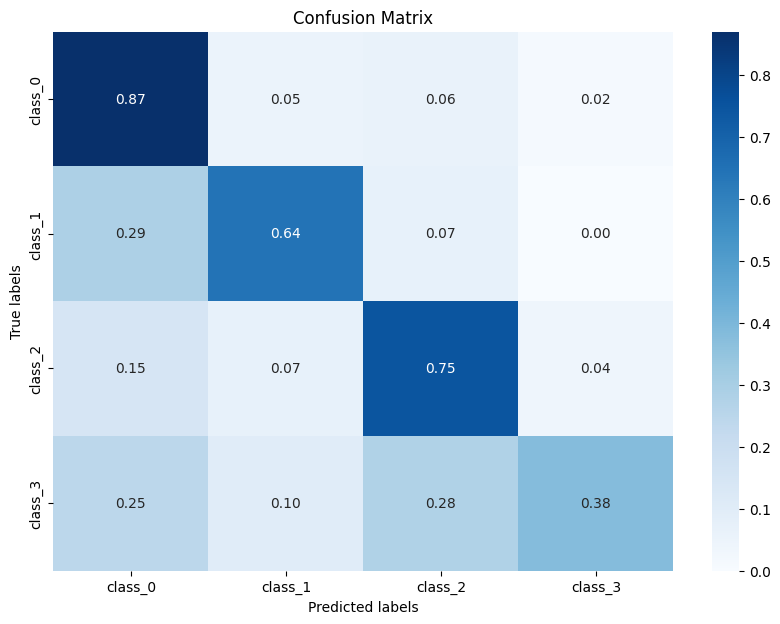

In [29]:
# Carica EEGNet allenato
eegnet_model.load_state_dict(torch.load("checkpoints/eegnet_model.pth"))
eegnet_model.eval()

# Test EEGNet (numerico)
eeg_eval = EvalModel(eegnet_model)
eegnet_acc = eeg_eval.test_model(TensorDataset(X_test, y_test))

print(f"\n{'='*50}")
print(f"CONFRONTO MODELLI")
print(f"{'='*50}")
print(f"EEGNet (numerico):     {eegnet_acc:.2f}%")
# print(f"EEGViT ({INPUT_METHOD}): {vit_acc:.2f}%")
print(f"{'='*50}")

# Test e confusion matrix
evaluator = EvalModel(eegnet_model)
test_acc = evaluator.test_model(test_dataset)

classes = ["class_0", "class_1", "class_2", "class_3"]
evaluator.plot_confusion_matrix(test_dataset, classes)


/------------------------------/
Test Accuracy: 22.35%
/------------------------------/

CONFRONTO MODELLI
EEGViT: 22.35%
/------------------------------/
Test Accuracy: 22.35%
/------------------------------/


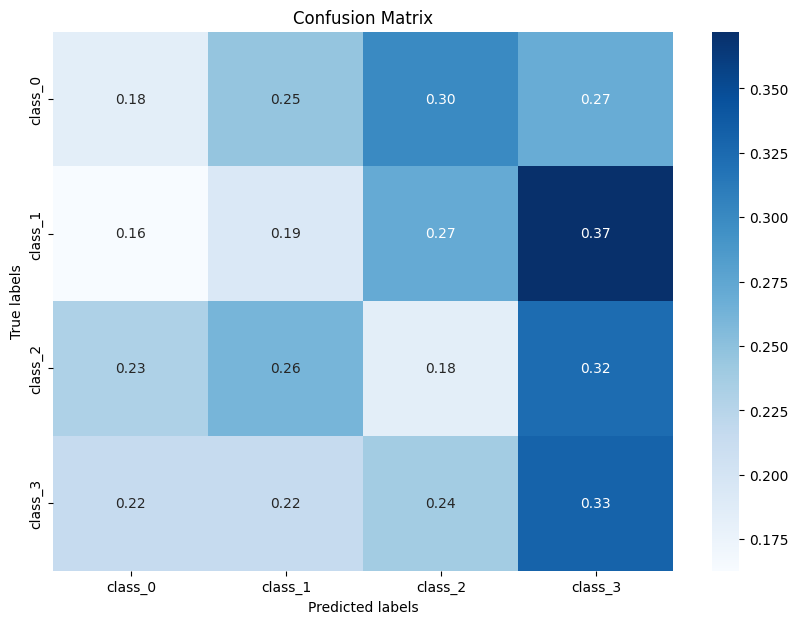

In [34]:
# # Test ViT (immagini)
# vit_eval = EvalModel(vit_trained)
# vit_acc = vit_eval.test_model(test_dataset_vit)

# Test EEGNet (numerico)
vit_eval = EvalModel(vit_model)
vit_acc = vit_eval.test_model(TensorDataset(X_test_vit, y_test))

print(f"\n{'='*50}")
print(f"CONFRONTO MODELLI")
print(f"{'='*50}")
print(f"EEGViT: {vit_acc:.2f}%")
print(f"{'='*50}")


# Test e confusion matrix
evaluator = EvalModel(vit_model)
test_acc = evaluator.test_model(test_dataset_vit)

classes = ["class_0", "class_1", "class_2", "class_3"]
evaluator.plot_confusion_matrix(test_dataset_vit, classes)